# Лабораторная работа №5 (часть 1). Ансамбли моделей: бэггинг и бустинг

**Курс:** Технологии машинного обучения

**Цель работы:** изучение ансамблевых моделей машинного обучения.

**Задание:**
1. Выбрать набор данных (датасет) для решения задачи классификации или регрессии.
2. В случае необходимости провести удаление или заполнение пропусков и кодирование категориальных признаков.
3. С использованием метода `train_test_split` разделить выборку на обучающую и тестовую.
4. Обучить следующие ансамблевые модели: две модели группы бэггинга (бэггинг, случайный лес или сверхслучайные деревья), AdaBoost, градиентный бустинг.
5. Оценить качество моделей с помощью подходящих для задачи метрик и сравнить качество полученных моделей.

Ссылка на постановку задания: https://github.com/ugapanyuk/courses_current/wiki/LAB_TMO_ENSEMBLES_1

## 1. Выбор набора данных

Используется датасет **Medical Cost Personal Datasets** с сайта [kaggle.com](https://www.kaggle.com/datasets/mirichoi0218/insurance) (автор — Miri Choi, идентификатор `mirichoi0218/insurance`). Датасет содержит данные о медицинских страховых расходах 1338 клиентов страховой компании.
Файл скачан с Kaggle и сохранён локально в `data/insurance.csv`.

Признаки: `age` (возраст), `sex` (пол), `bmi` (индекс массы тела), `children` (число детей), `smoker` (курильщик), `region` (регион проживания в США); целевой признак `charges` — индивидуальные медицинские расходы, оплаченные страховкой (в долларах США).

Решается задача **регрессии**: предсказать размер страховых расходов `charges` по характеристикам клиента.
Датасет подходит для задания: в нём есть **категориальные признаки** (`sex`, `smoker`, `region`), числовые признаки разного масштаба и нелинейная зависимость целевого признака от признаков (сильное взаимодействие `smoker` и `bmi`), на которой ансамблевые модели должны проявить себя.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import (BaggingRegressor, RandomForestRegressor, AdaBoostRegressor,
                              GradientBoostingRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

In [2]:
data = pd.read_csv("data/insurance.csv")
print("Размер набора данных:", data.shape)
data.head()

Размер набора данных: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
data.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


## 2. Разведочный анализ данных

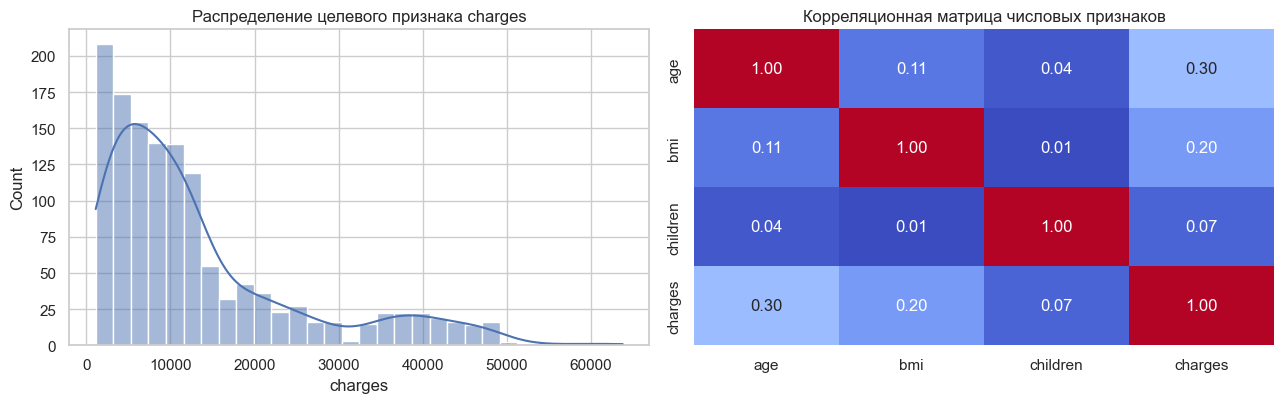

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.histplot(data["charges"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Распределение целевого признака charges")
corr = data.select_dtypes("number").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1], cbar=False)
axes[1].set_title("Корреляционная матрица числовых признаков")
plt.tight_layout(); plt.show()

## 3. Обработка пропусков и кодирование категориальных признаков

Проверяем набор данных на пропуски и дубликаты. Пропусков в датасете нет, поэтому заполнение не требуется; шаг `SimpleImputer` оставлен в конвейере как защитный (на новых данных пропуски могут появиться). Единственная полностью повторяющаяся строка (дубликат) удаляется.
Категориальные признаки `sex`, `smoker`, `region` кодируются One-Hot, числовые — стандартизуются. Вся предобработка собрана в `ColumnTransformer` и обучается только по обучающей выборке (нет утечки данных).

In [6]:
miss = data.isna().sum().to_frame("Пропусков")
miss["Доля, %"] = (miss["Пропусков"] / len(data) * 100).round(2)
print("Полных дубликатов строк:", data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)
print("Размер после удаления дубликатов:", data.shape)
for c in ["sex", "smoker", "region"]: print(c, "->", data[c].unique().tolist())
miss

Полных дубликатов строк: 1
Размер после удаления дубликатов: (1337, 7)
sex -> ['female', 'male']
smoker -> ['yes', 'no']
region -> ['southwest', 'southeast', 'northwest', 'northeast']


,Пропусков,"Доля, %"
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


## 4. Разделение выборки на обучающую и тестовую

In [7]:
X = data.drop(columns=["charges"])
y = data["charges"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)
print("Обучающая выборка:", X_train.shape, " Тестовая выборка:", X_test.shape)
print("charges: среднее train = %.0f, среднее test = %.0f" % (y_train.mean(), y_test.mean()))

Обучающая выборка: (1002, 6)  Тестовая выборка: (335, 6)
charges: среднее train = 13082, среднее test = 13868


In [8]:
num_cols = X.select_dtypes("number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])
Xtr = preprocess.fit_transform(X_train)
Xte = preprocess.transform(X_test)
feature_names = preprocess.get_feature_names_out()
print("Числовые:", num_cols); print("Категориальные:", cat_cols)
print("Признаков после преобразования:", Xtr.shape[1]); print(list(feature_names))

Числовые: ['age', 'bmi', 'children']
Категориальные: ['sex', 'smoker', 'region']
Признаков после преобразования: 11
['num__age', 'num__bmi', 'num__children', 'cat__sex_female', 'cat__sex_male', 'cat__smoker_no', 'cat__smoker_yes', 'cat__region_northeast', 'cat__region_northwest', 'cat__region_southeast', 'cat__region_southwest']


## 5. Обучение ансамблевых моделей

Обучаются четыре модели:
- **Бэггинг** (`BaggingRegressor` над деревьями решений) — группа бэггинга;
- **Случайный лес** (`RandomForestRegressor`) — группа бэггинга;
- **AdaBoost** (`AdaBoostRegressor`);
- **Градиентный бустинг** (`GradientBoostingRegressor`).

В качестве базовой линии добавлено одиночное дерево решений.

In [9]:
models = {
    "Дерево решений (база)": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Бэггинг": BaggingRegressor(DecisionTreeRegressor(), n_estimators=100, random_state=RANDOM_STATE),
    "Случайный лес": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostRegressor(DecisionTreeRegressor(max_depth=3), n_estimators=100,
                                  learning_rate=0.05, random_state=RANDOM_STATE),
    "Градиентный бустинг": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3,
                                                     random_state=RANDOM_STATE),
}
preds = {}
for name, m in models.items():
    m.fit(Xtr, y_train)
    preds[name] = m.predict(Xte)
    print("обучена:", name)

обучена: Дерево решений (база)


обучена: Бэггинг


обучена: Случайный лес
обучена: AdaBoost
обучена: Градиентный бустинг


## 6. Оценка качества моделей

Для задачи регрессии используются метрики: **MAE** (средняя абсолютная ошибка, в долларах), **RMSE** (корень из среднеквадратичной ошибки) и **R²** (коэффициент детерминации). Дополнительно — средний R² при 5-кратной кросс-валидации на обучающей выборке.

In [10]:
kf = KFold(5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, m in models.items():
    p = preds[name]
    cv = cross_val_score(m, Xtr, y_train, cv=kf, scoring="r2").mean()
    rows.append({"Модель": name,
                 "MAE": mean_absolute_error(y_test, p),
                 "RMSE": mean_squared_error(y_test, p) ** 0.5,
                 "R2": r2_score(y_test, p),
                 "R2 (CV, 5 фолдов)": cv})
res = pd.DataFrame(rows).set_index("Модель").round(4)
res.sort_values("R2", ascending=False)

,MAE,RMSE,R2,"R2 (CV, 5 фолдов)"
Модель,,,,
Градиентный бустинг,2586.1341,4469.6245,0.8845,0.8332
Случайный лес,2606.4644,4693.1367,0.8726,0.8233
Бэггинг,2626.4846,4731.7924,0.8705,0.8229
AdaBoost,4194.0489,5076.6920,0.8509,0.8141
Дерево решений (база),2756.0354,5998.1337,0.7919,0.6786


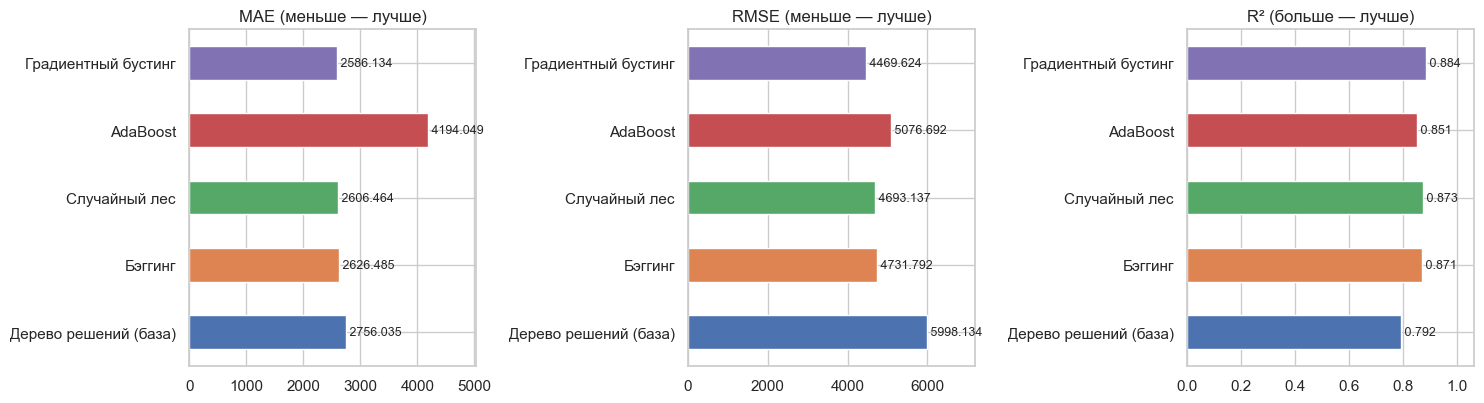

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, title in zip(axes, ["MAE", "RMSE", "R2"], ["MAE (меньше — лучше)", "RMSE (меньше — лучше)", "R² (больше — лучше)"]):
    res[col].plot.barh(ax=ax, color=sns.color_palette("deep", len(res)))
    ax.set_title(title); ax.set_ylabel("")
    for i, v in enumerate(res[col]): ax.text(v, i, " %.3f" % v, va="center", fontsize=9)
    ax.margins(x=0.2)
plt.tight_layout(); plt.show()

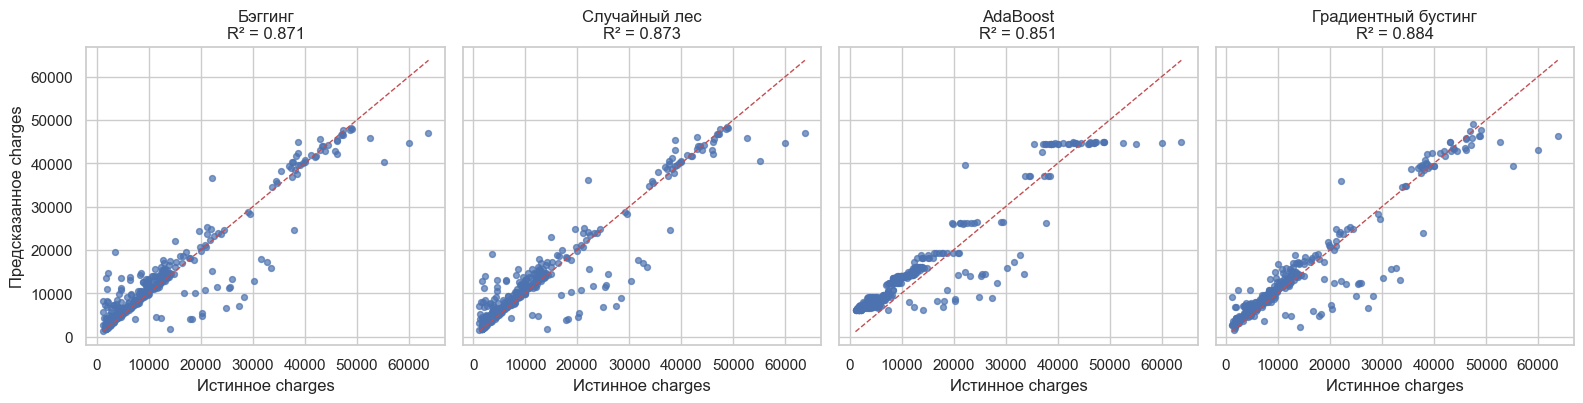

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), sharex=True, sharey=True)
lim = [y.min() - 1, y.max() + 1]
for ax, name in zip(axes, list(models)[1:]):
    ax.scatter(y_test, preds[name], s=18, alpha=.7)
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_title("%s\nR² = %.3f" % (name, r2_score(y_test, preds[name])))
    ax.set_xlabel("Истинное charges")
axes[0].set_ylabel("Предсказанное charges")
plt.tight_layout(); plt.show()

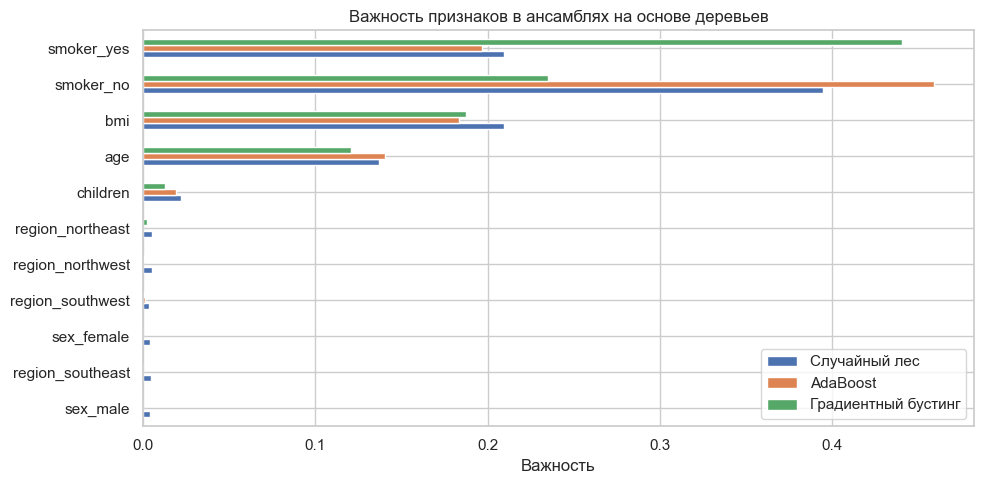

In [13]:
imp = pd.DataFrame({name: models[name].feature_importances_ for name in ["Случайный лес", "AdaBoost", "Градиентный бустинг"]},
                   index=[f.split("__")[1] for f in feature_names])
imp.sort_values("Градиентный бустинг").plot.barh(figsize=(10, 5))
plt.title("Важность признаков в ансамблях на основе деревьев"); plt.xlabel("Важность"); plt.tight_layout(); plt.show()

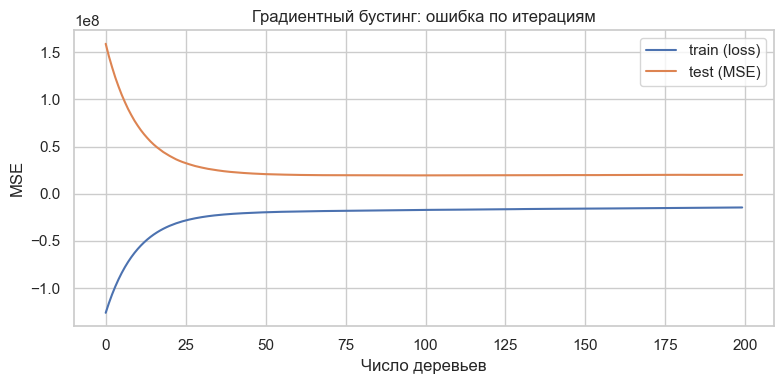

In [14]:
# Зависимость ошибки градиентного бустинга от числа деревьев (на тесте)
gb = models["Градиентный бустинг"]
test_mse = [mean_squared_error(y_test, p) for p in gb.staged_predict(Xte)]
train_mse = gb.train_score_ * -1
plt.figure(figsize=(8, 4))
plt.plot(train_mse, label="train (loss)"); plt.plot(test_mse, label="test (MSE)")
plt.xlabel("Число деревьев"); plt.ylabel("MSE"); plt.legend(); plt.title("Градиентный бустинг: ошибка по итерациям")
plt.tight_layout(); plt.show()

## 7. Выводы

- Выбран датасет Medical Cost Personal Datasets с Kaggle (`mirichoi0218/insurance`), задача регрессии (`charges`). Пропусков нет, найден и удалён один дубликат (1338 → 1337 строк); `sex`, `smoker`, `region` закодированы One-Hot, числовые признаки стандартизованы. Предобработка обучается только на train.
- Выборка разделена `train_test_split` (75/25): 1002 объекта в обучении и 335 в тесте.
- Обучены две модели бэггинга (бэггинг над деревьями и случайный лес), AdaBoost и градиентный бустинг; одиночное дерево решений использовано как базовая линия.
- Все ансамбли лучше одиночного дерева (R² 0.792 → 0.851–0.885, RMSE 5998 → 4470–5077 долларов): усреднение и последовательная коррекция снижают дисперсию и переобучение глубокого дерева. Особенно заметен выигрыш по кросс-валидации: у одиночного дерева R² = 0.679, у ансамблей 0.814–0.833.
- **Лучший результат у градиентного бустинга**: R² = 0.885, MAE = 2586, RMSE = 4470 на тесте и лучший средний R² по кросс-валидации (0.833). Следом идут случайный лес (R² = 0.873, CV 0.823) и бэггинг (R² = 0.871, CV 0.823); эти две модели почти неотличимы.
- **AdaBoost** — самый слабый ансамбль (R² = 0.851, CV 0.814), причём его MAE = 4194 заметно хуже, чем у остальных (около 2600): AdaBoost систематически завышает предсказания (средняя ошибка на тесте +2089 долларов, для клиентов с расходами меньше 10000 — около +3800), тогда как у остальных ансамблей смещение не превышает 350. Параметры (глубина 3, learning_rate = 0.05) подобраны по кросс-валидации только на обучающей выборке.
- Наиболее значимые признаки — статус курильщика (`smoker`), индекс массы тела `bmi` и возраст `age`; `children` даёт малый вклад, а пол и регион почти не влияют (см. график важности признаков). Это согласуется со структурой данных: расходы курильщиков с высоким `bmi` резко выше, такую нелинейность деревья ловят автоматически.
- Различия между градиентным бустингом, случайным лесом и бэггингом невелики (около 0.01–0.015 по R²) и сопоставимы с разбросом из-за размера тестовой выборки (335 объектов), поэтому превосходство градиентного бустинга нужно считать умеренным, а не абсолютным.